# 03 - Recuperacion de precedentes similares

## Resumen amplio

Este notebook implementa retrieval de precedentes. Dado un caso de consulta, ordena casos de entrenamiento por similitud textual para que una persona revise precedentes potencialmente utiles. No afirma identidad juridica ni predice sentencia.

Se comparan TF-IDF + coseno y TF-IDF + SVD + coseno. La relevancia operacional se define como compartir al menos un articulo real con la consulta. Es una aproximacion cuantitativa util, pero no sustituye validacion doctrinal humana.

## Indice

1. Carga de casos y etiquetas.
2. Definicion de relevancia y metricas.
3. TF-IDF + coseno.
4. SVD + coseno.
5. Ejemplo real de consulta y precedentes.
6. Figura y artefactos.


![Esquema especifico generado con Image Gen](artifacts/figures/generated/notebook_03_retrieval_v2.png)

**Lectura del esquema.** La imagen resume retrieval: una consulta real se compara contra un indice construido solo con train y devuelve un ranking top-k de precedentes candidatos. La imagen es conceptual; las cifras y conclusiones se calculan en las celdas del notebook con datos reales.


In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import project_utils as pu
warnings.filterwarnings('ignore')
pu.configure(); sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 180)


## 1. Datos para retrieval

El indice contiene solo `train`; las consultas vienen de `validation` y `test`. La muestra hace el notebook interactivo y reproducible.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
import joblib

pu.materialize_database(force=False)
cases, labels, articles = pu.load_cases_labels()
y = pu.multilabel_matrix(labels, cases['case_id'], articles)
case_labels_sets = {case_id: set(y.columns[y.loc[case_id].to_numpy().astype(bool)]) for case_id in y.index}
train = cases[cases['split']=='train'].sample(n=2500, random_state=pu.SEED).sort_values('case_id').reset_index(drop=True)
queries = pd.concat([cases[cases['split']=='validation'].sample(n=250, random_state=pu.SEED), cases[cases['split']=='test'].sample(n=250, random_state=pu.SEED)]).sort_values(['split','case_id']).reset_index(drop=True)
print(train.shape, queries.shape); display(train[['case_id','n_tokens']].head()); display(queries[['case_id','split','n_tokens']].head())


(2500, 7) (500, 7)


,case_id,n_tokens
0,ecthr_task_b_train_000000,7014
1,ecthr_task_b_train_000003,3907
2,ecthr_task_b_train_000008,1712
3,ecthr_task_b_train_000014,3214
4,ecthr_task_b_train_000017,828


,case_id,split,n_tokens
0,ecthr_task_b_test_000002,test,302
1,ecthr_task_b_test_000003,test,644
2,ecthr_task_b_test_000010,test,206
3,ecthr_task_b_test_000023,test,785
4,ecthr_task_b_test_000025,test,2160


## 2. Metricas de ranking

`Recall@5` y `Recall@10` indican si aparece al menos un precedente relevante en las primeras posiciones. `nDCG@10` premia que los relevantes aparezcan arriba.


In [3]:
def evaluate_rankings(method_name, query_df, train_df, score_matrix, top_k=10):
    """Evalua un ranking de precedentes con relevancia por articulos compartidos.

    Entrada:
        method_name: nombre del metodo de retrieval evaluado.
        query_df: consultas reales de validation/test.
        train_df: casos indexados como precedentes candidatos.
        score_matrix: matriz `(n_consultas, n_train)` con similitudes.
        top_k: profundidad maxima guardada y evaluada.

    Salida:
        `(rankings, metrics)`:
        - `rankings`: una fila por consulta y posicion recuperada.
        - `metrics`: Recall@5, Recall@10 y nDCG@10 por consulta.

    Criterio de relevancia:
        Un precedente cuenta como relevante si comparte al menos un articulo real
        con la consulta. Es una definicion operacional para evaluar a escala, no
        una equivalencia juridica completa.
    """
    rows=[]; metric_rows=[]; train_ids=train_df['case_id'].tolist()
    for q_idx, q in query_df.iterrows():
        order=np.argsort(score_matrix[q_idx])[::-1][:top_k]; q_labels=case_labels_sets[q['case_id']]; relevances=[]
        for rank, train_pos in enumerate(order, start=1):
            retrieved=train_ids[train_pos]; relevant=int(bool(q_labels & case_labels_sets[retrieved])); relevances.append(relevant)
            rows.append({'query_case_id':q['case_id'],'rank':rank,'retrieved_case_id':retrieved,'relevant':relevant,'score':float(score_matrix[q_idx,train_pos]),'split':q['split'],'method':method_name})
        metric_rows.append({'retrieval_method':method_name,'split':q['split'],'query_case_id':q['case_id'],'has_relevant':int(any(relevances)),'recall_at_5':pu.recall_at_k(relevances,5),'recall_at_10':pu.recall_at_k(relevances,10),'ndcg_at_10':pu.ndcg_at_k(relevances,10)})
    return pd.DataFrame(rows), pd.DataFrame(metric_rows)


## 3. TF-IDF + coseno

Coseno compara direccion de vectores, no longitud. Esto ayuda con documentos juridicos de tamanos muy distintos.


In [4]:
retrieval_vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95, max_features=80000, sublinear_tf=True, strip_accents='unicode', lowercase=True, dtype=np.float32)
train_x = retrieval_vectorizer.fit_transform(train['text_full']); query_x = retrieval_vectorizer.transform(queries['text_full'])
tfidf_scores = cosine_similarity(query_x, train_x)
tfidf_rankings, tfidf_metrics = evaluate_rankings('tfidf_cosine_sampled', queries, train, tfidf_scores)
display(tfidf_metrics.groupby(['retrieval_method','split']).agg(n_queries=('query_case_id','count'), n_queries_with_relevant=('has_relevant','sum'), ndcg_at_10=('ndcg_at_10','mean'), recall_at_5=('recall_at_5','mean'), recall_at_10=('recall_at_10','mean')).reset_index())


,retrieval_method,split,n_queries,n_queries_with_relevant,ndcg_at_10,recall_at_5,recall_at_10
0,tfidf_cosine_sampled,test,250,243,0.866788,0.944,0.972
1,tfidf_cosine_sampled,validation,250,241,0.881982,0.952,0.964


## 4. TF-IDF + SVD + coseno

SVD no es red neuronal: es una proyeccion lineal densa. Se incluye para comparar espacio disperso frente a representacion compacta.


In [5]:
svd = TruncatedSVD(n_components=256, random_state=pu.SEED)
train_z = svd.fit_transform(train_x); query_z = svd.transform(query_x)
svd_scores = cosine_similarity(query_z, train_z)
svd_rankings, svd_metrics = evaluate_rankings('tfidf_svd_cosine_sampled', queries, train, svd_scores)
headline = pd.concat([tfidf_metrics, svd_metrics]).groupby(['retrieval_method','split']).agg(n_queries=('query_case_id','count'), n_queries_with_relevant=('has_relevant','sum'), ndcg_at_10=('ndcg_at_10','mean'), recall_at_5=('recall_at_5','mean'), recall_at_10=('recall_at_10','mean')).reset_index()
headline.to_csv(pu.METRICS/'retrieval_tfidf_headline.csv', index=False); headline.to_csv(pu.METRICS/'paper_retrieval_table.csv', index=False)
rankings = pd.concat([tfidf_rankings, svd_rankings], ignore_index=True); rankings.to_csv(pu.METRICS/'retrieval_tfidf_rankings.csv', index=False)
joblib.dump({'vectorizer':retrieval_vectorizer,'svd':svd,'train_case_ids':train['case_id'].tolist()}, pu.INDICES/'notebook_retrieval_tfidf_svd_index.joblib')
display(headline)


,retrieval_method,split,n_queries,n_queries_with_relevant,ndcg_at_10,recall_at_5,recall_at_10
0,tfidf_cosine_sampled,test,250,243,0.866788,0.944,0.972
1,tfidf_cosine_sampled,validation,250,241,0.881982,0.952,0.964
2,tfidf_svd_cosine_sampled,test,250,239,0.876653,0.940,0.956
3,tfidf_svd_cosine_sampled,validation,250,241,0.899043,0.964,0.964


### Interpretacion de la tabla de retrieval

`Recall@10` responde a una pregunta practica: si el usuario revisa diez precedentes, aparece al menos uno que comparte articulo real con la consulta? `nDCG@10` es mas exigente porque premia que ese precedente aparezca arriba. Una puntuacion alta no significa que el precedente sea doctrinalmente equivalente; significa que, bajo la definicion operacional de relevancia, el ranking pone casos utiles pronto.

La variante SVD puede mejorar `nDCG` porque agrupa patrones de vocabulario, pero tambien pierde interpretabilidad directa: ya no se puede explicar el ranking solo mirando terminos TF-IDF originales.


## 5. Ejemplo real de precedentes recuperados

La consulta y los precedentes son casos reales. Se muestran articulos compartidos para interpretar la relevancia operacional.


In [6]:
query_id = rankings[(rankings['split']=='test') & (rankings['method']=='tfidf_cosine_sampled')].iloc[0]['query_case_id']
display(pd.DataFrame([pu.summarize_case(query_id, max_chars=900)]))
example_rank = rankings[(rankings['query_case_id']==query_id) & (rankings['method']=='tfidf_cosine_sampled')].head(5)
rows=[]
for row in example_rank.itertuples(index=False):
    s=pu.summarize_case(row.retrieved_case_id, max_chars=450); shared=sorted(case_labels_sets[query_id] & case_labels_sets[row.retrieved_case_id])
    rows.append({'rank':row.rank,'retrieved_case_id':row.retrieved_case_id,'score':row.score,'relevant':row.relevant,'shared_articles':', '.join(shared),'retrieved_excerpt':s['excerpt']})
display(pd.DataFrame(rows))


,case_id,task,split,year,n_paragraphs,n_tokens,excerpt,article_codes
0,ecthr_task_b_test_000002,ecthr_task_b,test,None,8,302,5. The applicant was born in 1965 and lives in Smědčice. 6. On 9 November 2006 the applicant requested a building permit for temporary stables for horses. On 6 January 2011 ...,6


,rank,retrieved_case_id,score,relevant,shared_articles,retrieved_excerpt
0,1,ecthr_task_b_train_008248,0.163510,1,6,5. The applicant was born in 1952 and lives in Šaľa. 6. On 31 May 1994 the applicant claimed a sum of money from a bank. 7. On 16 September 2005 the applicant lodged an ap...
1,2,ecthr_task_b_train_005972,0.145823,0,,"5. The applicant is a Czech national born in 1946 who lives in Vysoké Mýto (the Czech Republic). 6. The applicant was married from 1971 until 1998, when he divorced. On 28 M..."
2,3,ecthr_task_b_train_008569,0.143371,0,,"6. The applicants were born in 1972, 1949 and 1950 respectively. The first applicant lives in Sydney, Australia and the second and third applicants live in Skopje. 7. On 19 ..."
3,4,ecthr_task_b_train_001783,0.133637,1,6,"4. The applicant was born in 1948 and lives in Prague. 5. The applicant’s grandmother owned a house and plot of land in Městec Králové, which the State seized in 1960 and re..."
4,5,ecthr_task_b_train_007165,0.130844,1,6,"4. The applicant was born in 1965 and lives in Willstätt, Germany. He was a minority shareholder of IVAX CR, a.s., a joint stock company incorporated under Czech law. 5. On ..."


## 6. Figura y resultado

`Recall@10` es especialmente importante porque mide si la lista corta contiene al menos un precedente con articulo compartido.


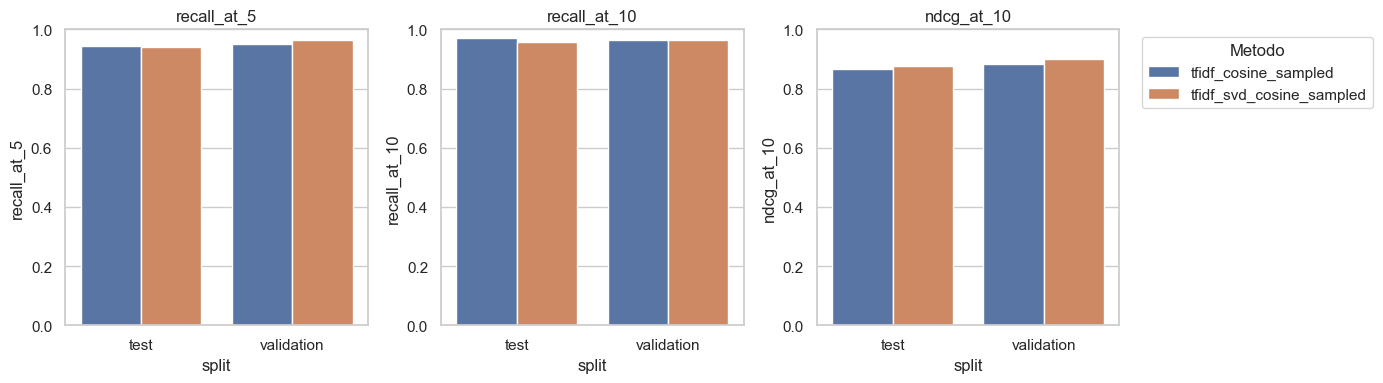

In [7]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, metric in zip(axes, ['recall_at_5','recall_at_10','ndcg_at_10']):
    sns.barplot(data=headline,x='split',y=metric,hue='retrieval_method',ax=ax); ax.set_ylim(0,1); ax.set_title(metric)
axes[0].legend_.remove(); axes[1].legend_.remove(); axes[2].legend(title='Metodo', bbox_to_anchor=(1.05,1), loc='upper left')
fig.tight_layout(); fig.savefig(pu.FIGURES/'fig05_retrieval_precedents.png', dpi=180); plt.show()
